1. https://kosis.kr/search/search.do 접속
2. 출입국 항구/내외국인/성별 국제이동(연간) 검색
3. 항목(우측사이드): 입국자,출국자,인천공항,내외국인,남여,기간선택
4. 피봇테이블 설정
   
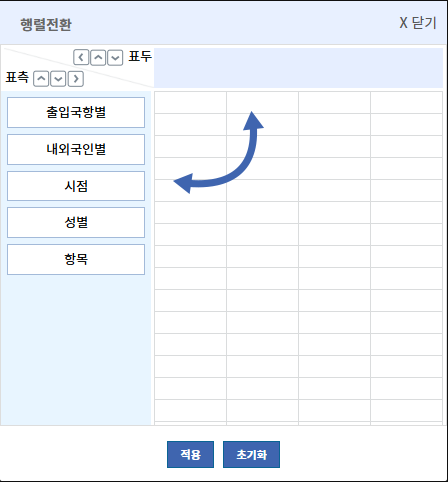

Text(0.2, 0.4, '한글')

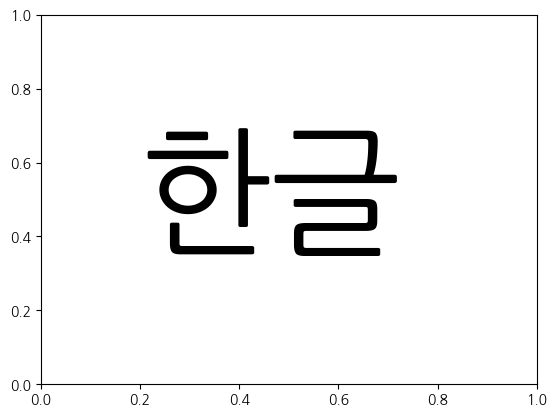

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.text(0.2,0.4, '한글', size=100)

In [2]:
file_path = "dataset/인천공항이용자수20260605_lite.csv"
raw = pd.read_csv(file_path, encoding="utf-8")
raw.sample(5)

,출입국항별,내외국인별,시점,성별,항목,데이터
28,인천공항,내국인,2017,남자,입국자,132564
78,인천공항,외국인,2015,여자,입국자,143525
40,인천공항,외국인,2024,남자,입국자,213978
38,인천공항,내국인,2015,여자,입국자,124534
67,인천공항,외국인,2018,여자,출국자,130711


In [3]:
# 컬럼명 바꾸기
ex1_data = raw.copy()
# 방법1
# ex1_data.columns = ['airport', 'type1', 'year', 'gender', 'type2', 'value']
# 방법2
ex1_data.rename(columns={
    '출입국항별':'airport', 
    '내외국인별':'type1', 
    '시점':'year', 
    '성별':'gender', 
    '항목':'type2', 
    '데이터':'value'} , inplace=True )
ex1_data.columns 

Index(['airport', 'type1', 'year', 'gender', 'type2', 'value'], dtype='object')

In [4]:
# 필터제작
filter1 = ex1_data['type1']=='외국인'
ex2_data = ex1_data[filter1].copy()
ex2_data.head()

,airport,type1,year,gender,type2,value
40,인천공항,외국인,2024,남자,입국자,213978
41,인천공항,외국인,2024,남자,출국자,161611
42,인천공항,외국인,2024,여자,입국자,169391
43,인천공항,외국인,2024,여자,출국자,136567
44,인천공항,외국인,2023,남자,입국자,238300


In [5]:
# 년도별 통계
ex1_total = ex1_data.groupby('year')['value'].sum().reset_index(name='total')
ex1_total #.plot()
# plt.show()

,year,total
0,2015,1092457
1,2016,1120463
2,2017,1171045
3,2018,1227720
4,2019,1198598
5,2020,1129092
6,2021,867277
7,2022,1073387
8,2023,1124211
9,2024,1136691


In [6]:
filter2_in = ex2_data['type2']=='입국자'
ex2_in = ex2_data[filter2_in]
filter2_out = ex2_data['type2']=='출국자'
ex2_out = ex2_data[filter2_out]
ex2_in = ex2_in.groupby('year')['value'].sum().reset_index(name="intotal")
ex2_out = ex2_out.groupby('year')['value'].sum().reset_index(name="outtotal")

<Axes: title={'center': '2015 ~ 2024년 인천공항 입국 외국인 차트'}>

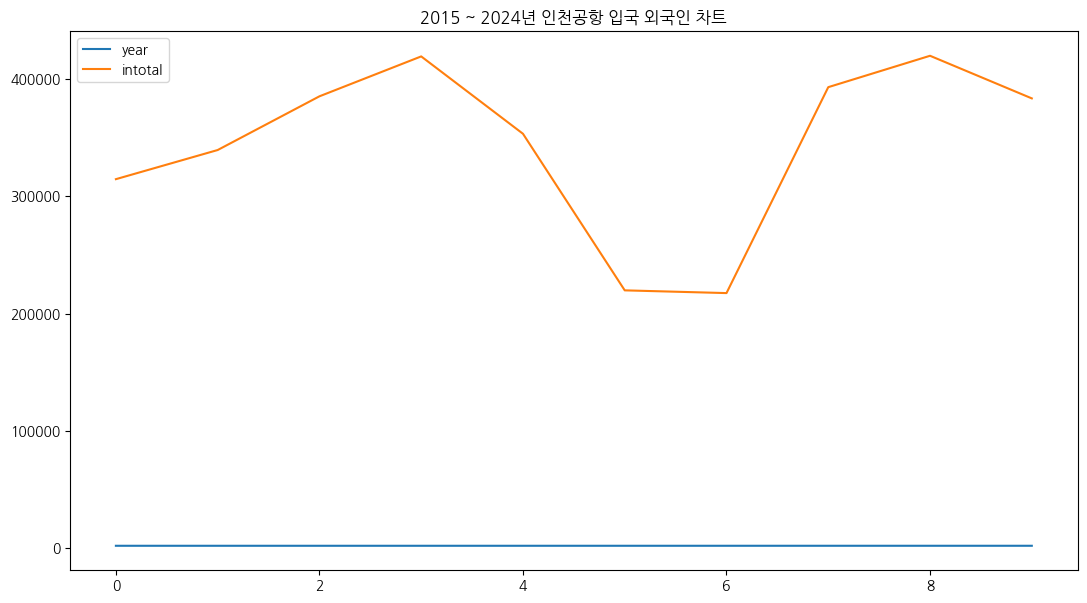

In [7]:
ex2_in.plot(figsize=(13,7),title="2015 ~ 2024년 인천공항 입국 외국인 차트")

<Axes: title={'center': '2015 ~ 2024년 인천공항 출국 외국인 차트'}>

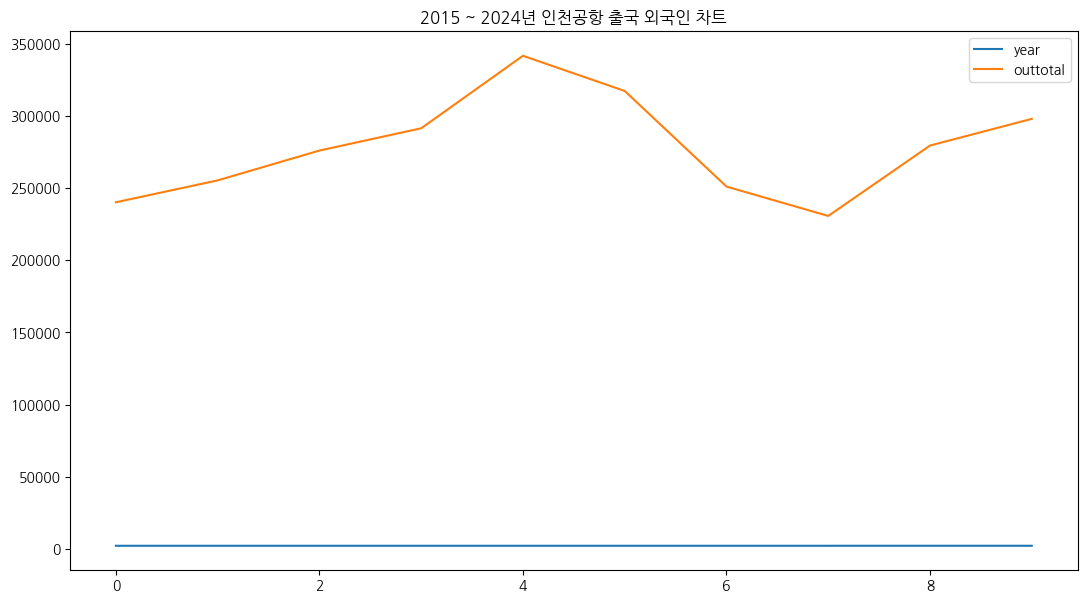

In [8]:
ex2_out.plot(figsize=(13,7),title="2015 ~ 2024년 인천공항 출국 외국인 차트")

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "dataset/인천공항이용자수20260605.csv"
raw = pd.read_csv(file_path, encoding="cp949")  # 혹은 상황에 맞는 인코딩
raw.sample(5)

,출입국항별,시점,내외국인별,항목,성별,데이터
52,인천공항,2007,외국인,입국자,남자,137054
33,인천공항,2005,내국인,입국자,여자,121853
175,인천공항,2022,외국인,출국자,여자,106797
142,인천공항,2018,외국인,출국자,남자,160929
98,인천공항,2013,내국인,출국자,남자,151941


In [10]:
# 1. 컬럼명 영문으로 통일 (오타 방지)
ex1_data = raw.copy()
ex1_data.rename(columns={
    '출입국항별': 'airport', 
    '내외국인별': 'type1', 
    '시점': 'year', 
    '성별': 'gender', 
    '항목': 'type2', 
    '데이터': 'value'
}, inplace=True)

# 2. '외국인' 데이터만 필터링
filter1 = ex1_data['type1'] == '외국인'
ex2_data = ex1_data[filter1].copy()

# 3. 입국자 / 출국자 분리 후 연도별 합계(groupby) 계산
filter2_in = ex2_data['type2'] == '입국자'
ex2_in = ex2_data[filter2_in].groupby('year')['value'].sum().reset_index(name="intotal")

filter2_out = ex2_data['type2'] == '출국자'
ex2_out = ex2_data[filter2_out].groupby('year')['value'].sum().reset_index(name="outtotal")

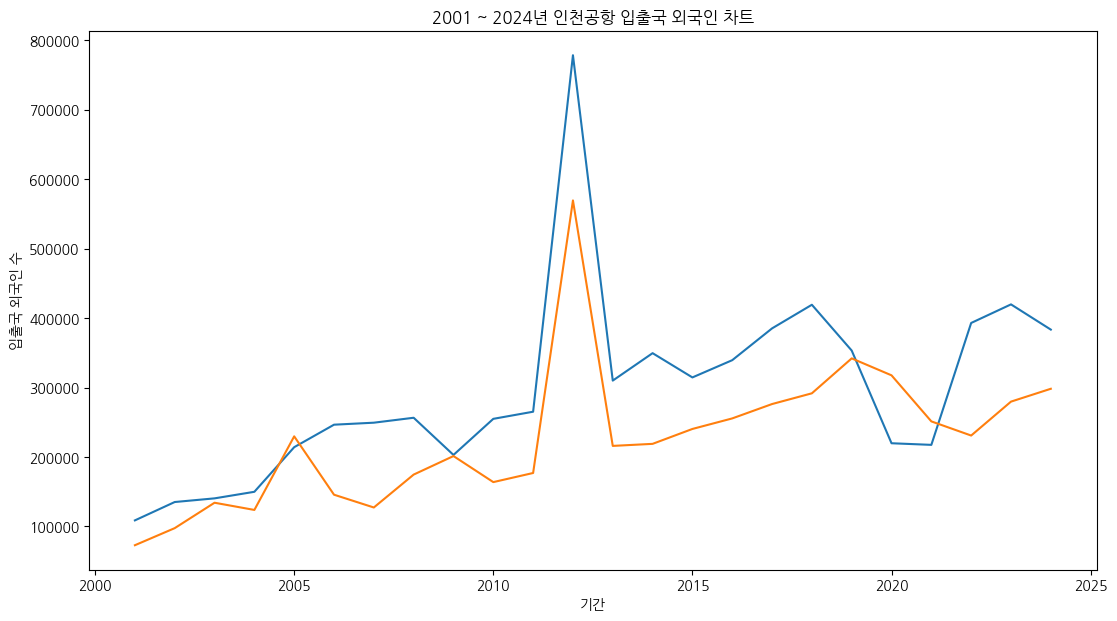

In [11]:
# ex2_in , ex2_out
import matplotlib.pyplot as plt

plt.rc('font', family='NanumGothic')

plt.rc('axes', unicode_minus=False)

plt.figure(figsize=(13,7))
plt.plot(ex2_in['year'],ex2_in['intotal'])
plt.plot(ex2_out['year'],ex2_out['outtotal'])
plt.title("2001 ~ 2024년 인천공항 입출국 외국인 차트")
plt.xlabel("기간")
plt.ylabel("입출국 외국인 수")
plt.savefig("./인천공항입출국차트.png")
plt.show()

In [12]:
# !pip install prophet
# !pip install plotly

In [13]:
from prophet import Prophet # time 은 ds, value 는 y 전처리필요

In [14]:
pro_data = ex2_in.copy()
pro_data['year'] = pd.to_datetime(pro_data['year'],format="%Y")
pro_data.rename(columns={'year': 'ds', 'intotal': 'y'}, inplace=True)
pro_data.head()

,ds,y
0,2001-01-01,108662
1,2002-01-01,135099
2,2003-01-01,140375
3,2004-01-01,149826
4,2005-01-01,214051


In [15]:
m = Prophet()
m.fit(pro_data)

02:51:34 - cmdstanpy - INFO - Chain [1] start processing
02:51:34 - cmdstanpy - INFO - Chain [1] done processing


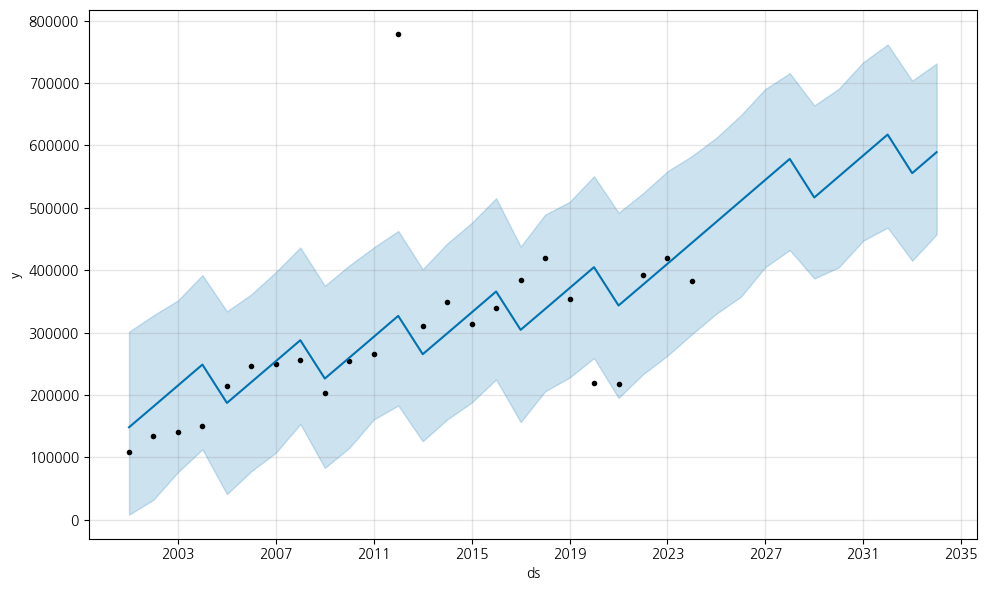

In [16]:
future = m.make_future_dataframe(periods=10, freq='YE')
forecast = m.predict(future)
fig1 = m.plot(forecast)
plt.savefig("./인천공항입출국차트(10년예측).png")
plt.show()

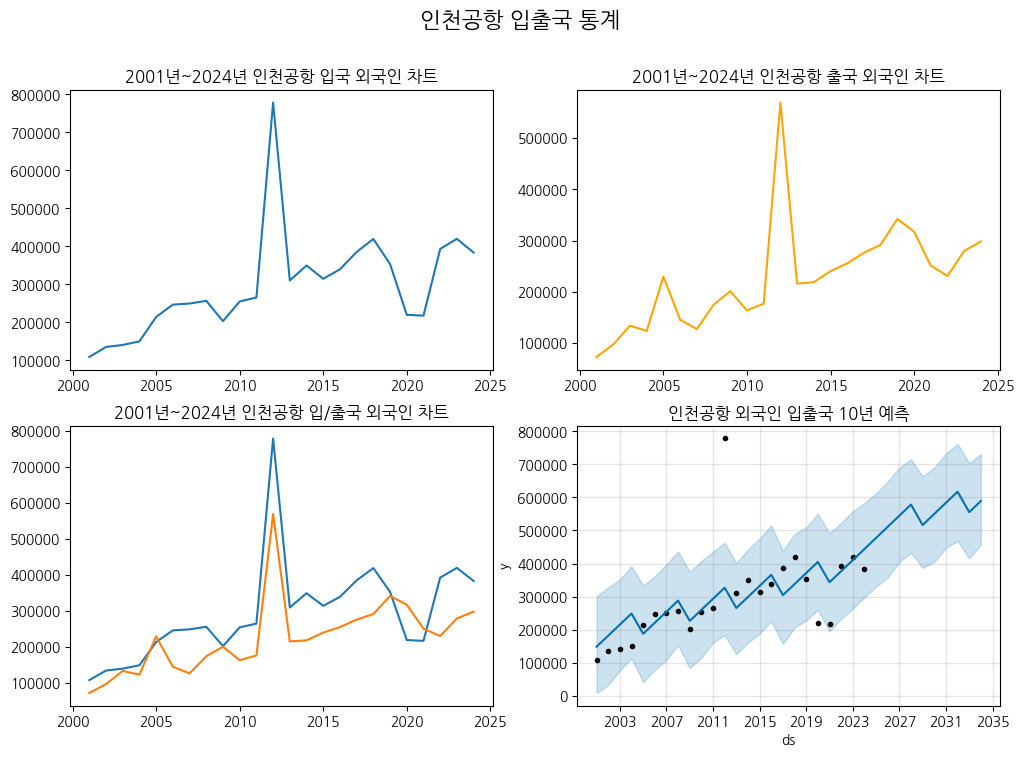

In [17]:
import matplotlib.pyplot as plt

fig , ax = plt.subplots(2,2,figsize=(12,8))
ax[0,0].plot(ex2_in['year'],ex2_in['intotal'])
ax[0,1].plot(ex2_out['year'],ex2_out['outtotal'], color='orange')
ax[1,0].plot(ex2_in['year'],ex2_in['intotal'])
ax[1,0].plot(ex2_out['year'],ex2_out['outtotal'])
m.plot(forecast, ax=ax[1,1])

fig.suptitle('인천공항 입출국 통계', fontsize=16)
ax[0,0].set_title("2001년~2024년 인천공항 입국 외국인 차트")
ax[0,1].set_title("2001년~2024년 인천공항 출국 외국인 차트")
ax[1,0].set_title("2001년~2024년 인천공항 입/출국 외국인 차트")
ax[1,1].set_title("인천공항 외국인 입출국 10년 예측")
plt.savefig('인천공항입출국통계total.png')
plt.show()

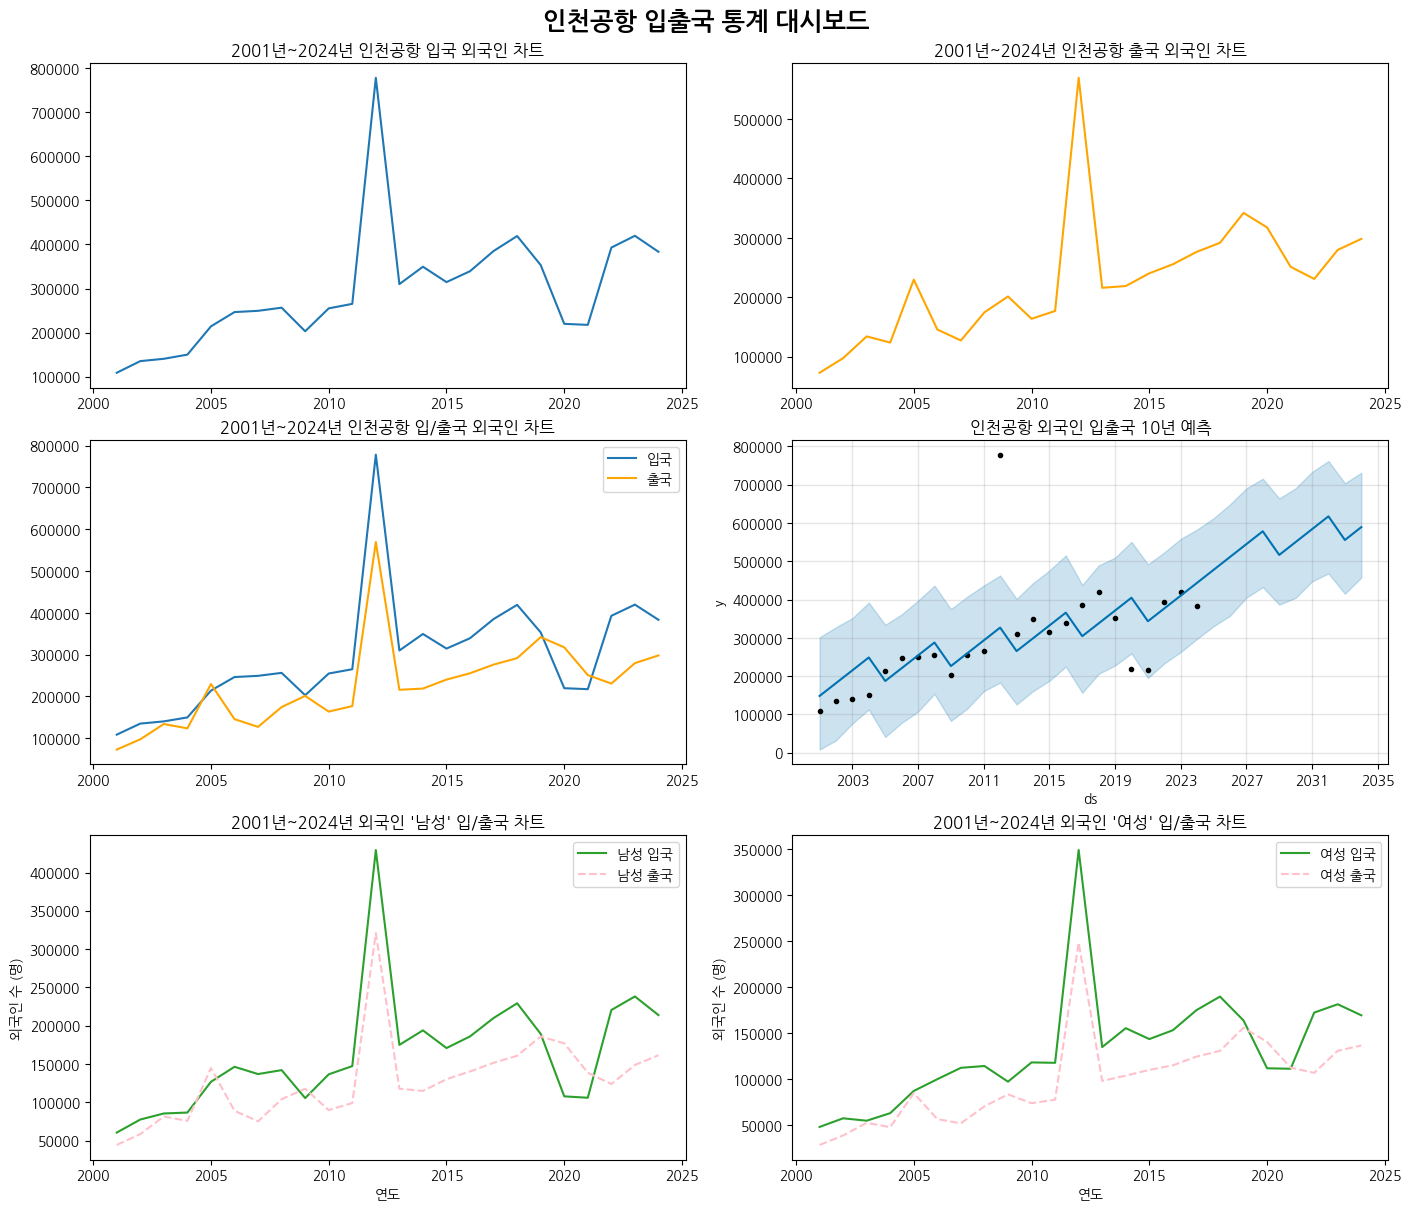

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. DATA GROUPING (SQL GROUP BY 구조 반영)
# ==========================================

# 외국인 전체 대상 필터링
filter_foreign = ex1_data['type1'] == '외국인'
ex2_data = ex1_data[filter_foreign].copy()

# 공통 조건 필터 정의
filter_in = ex2_data['type2'] == '입국자'
filter_out = ex2_data['type2'] == '출국자'
filter_male = ex2_data['gender'] == '남자'
filter_female = ex2_data['gender'] == '여자'

# [SQL] GROUP BY year (전체 입국 / 출국)
ex2_in = ex2_data[filter_in].groupby('year')['value'].sum().reset_index(name="intotal")
ex2_out = ex2_data[filter_out].groupby('year')['value'].sum().reset_index(name="outtotal")

# [SQL] WHERE gender = '남자' GROUP BY year
ex3_male_in = ex2_data[filter_male & filter_in].groupby('year')['value'].sum().reset_index(name='male_in')
ex3_male_out = ex2_data[filter_male & filter_out].groupby('year')['value'].sum().reset_index(name='male_out')

# [SQL] WHERE gender = '여자' GROUP BY year
ex3_female_in = ex2_data[filter_female & filter_in].groupby('year')['value'].sum().reset_index(name='female_in')
ex3_female_out = ex2_data[filter_female & filter_out].groupby('year')['value'].sum().reset_index(name='female_out')


# ==========================================
# 2. DASHBOARD VISUALIZATION (subplots 3, 2)
# ==========================================

# 한글 깨짐 방지 세팅
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

# 3행 2열 격자 생성 및 고정 레이아웃 배정
fig, ax = plt.subplots(3, 2, figsize=(14, 12), layout='constrained')

# [1행] 전체 입국 / 출국 개별 차트
ax[0,0].plot(ex2_in['year'], ex2_in['intotal'], color='tab:blue')
ax[0,0].set_title("2001년~2024년 인천공항 입국 외국인 차트")

ax[0,1].plot(ex2_out['year'], ex2_out['outtotal'], color='orange')
ax[0,1].set_title("2001년~2024년 인천공항 출국 외국인 차트")


# [2행] 입출국 혼합 트렌드 / Prophet 시계열 예측 결과
ax[1,0].plot(ex2_in['year'], ex2_in['intotal'], label='입국')
ax[1,0].plot(ex2_out['year'], ex2_out['outtotal'], label='출국', color='orange')
ax[1,0].set_title("2001년~2024년 인천공항 입/출국 외국인 차트")
ax[1,0].legend()

m.plot(forecast, ax=ax[1,1])
ax[1,1].set_title("인천공항 외국인 입출국 10년 예측")


# [3행] 성별 집계 차트 (남성 vs 여성)
# 남성 입출국
ax[2,0].plot(ex3_male_in['year'], ex3_male_in['male_in'], label='남성 입국', color='tab:green')
ax[2,0].plot(ex3_male_out['year'], ex3_male_out['male_out'], label='남성 출국', color='pink', linestyle='--')
ax[2,0].set_title("2001년~2024년 외국인 '남성' 입/출국 차트")
ax[2,0].set_xlabel("연도")          # 🌟 X축 라벨 추가
ax[2,0].set_ylabel("외국인 수 (명)") # 🌟 Y축 라벨 추가
ax[2,0].legend()

# 여성 입출국
ax[2,1].plot(ex3_female_in['year'], ex3_female_in['female_in'], label='여성 입국', color='tab:green')
ax[2,1].plot(ex3_female_out['year'], ex3_female_out['female_out'], label='여성 출국', color='pink', linestyle='--')
ax[2,1].set_title("2001년~2024년 외국인 '여성' 입/출국 차트")
ax[2,1].set_xlabel("연도")          # 🌟 X축 라벨 추가
ax[2,1].set_ylabel("외국인 수 (명)") # 🌟 Y축 라벨 추가
ax[2,1].legend()


# 대시보드 타이틀 및 이미지 저장 마무리
fig.suptitle('인천공항 입출국 통계 대시보드', fontsize=18, fontweight='bold')
plt.savefig('인천공항입출국통계total.png')
plt.show()